# <b><font color='saddlebrown'>Доверительные интервалы</font></b>

In [1]:
# Импорт библиотек
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

### <b><font color='saddlebrown'>ДИ для среднего ГС</font></b>

Измерили рост 25 студентов. Средний рост составил 175 см, стандартное отклонение — 10 см.
Постройте 95%-ный доверительный интервал для среднего роста всех студентов.

In [2]:
# Генерируем выборку
data = np.random.normal(loc=175, scale=10, size=25)

In [9]:
# Рассчитайте доверительный интервал для небольшого размера выборки (n < 30) с помощью t-распределения
# 1. Вычислите среднее значение и стандартную ошибку
mean_students = np.mean(data)
sem = stats.sem(data)
# 2. Определите ДИ
confidence = 0.95
# 3. Вычислите ДИ
ci = stats.t.interval(confidence = confidence, 
                   df = len(data)-1, 
                   loc = mean_students, 
                   scale = sem)
# для больших выборок или с известным 𝜎:
# ci = stats.norm.interval(confidence = confidence, loc = mean_students, scale = sem)
ci

(np.float64(171.41428983109228), np.float64(181.00351827916012))

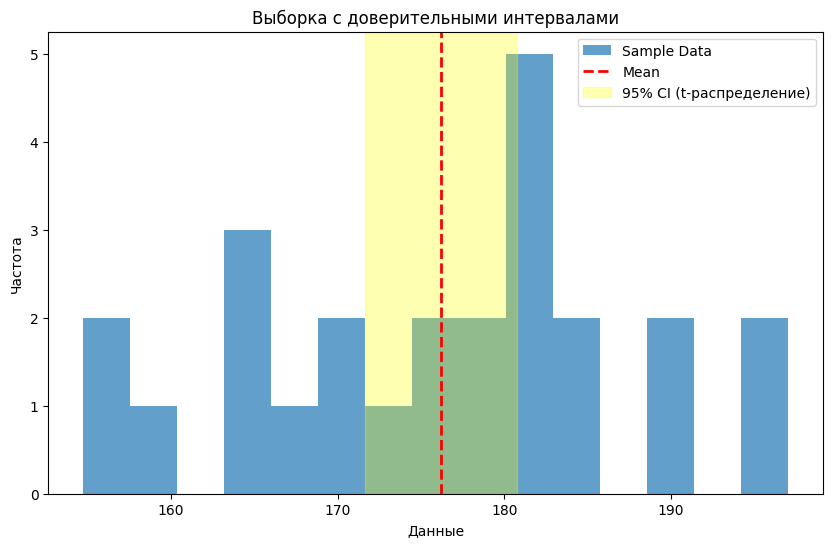

In [8]:
# Постройте визуализацию
# Построение графика данных выборки
plt.figure(figsize=(10, 6))
plt.hist(data, bins = 15, alpha = 0.7, label = 'Sample Data')

# Построение графика среднего значения
plt.axvline(mean_students, color = 'red', linestyle = 'dashed', linewidth = 2, label = 'Mean')

# Выделение доверительного интервала
plt.axvspan(ci[0], ci[1], color = 'yellow', alpha = 0.3, label = '95% CI (t-распределение)')

plt.xlabel('Данные')
plt.ylabel('Частота')
plt.title('Выборка с доверительными интервалами')
plt.legend()
plt.show()

### <b><font color='saddlebrown'>ДИ для доли ГС</font></b>

Из 200 опрошенных человек 120 ответили, что предпочитают чай кофе.
Постройте 95%-ный доверительный интервал для доли всех людей, предпочитающих чай.

In [6]:
from statsmodels.stats.proportion import proportion_confint

# Данные
n = 200
x = 120
confidence = 0.95
alpha = 1 - confidence

# Расчёт доверительного интервала
lower, upper = proportion_confint(count = x, nobs = n, alpha = alpha, method = 'normal')

print(f"95%-ный доверительный интервал для доли: ({lower:.3f}, {upper:.3f})")

95%-ный доверительный интервал для доли: (0.532, 0.668)


### <b><font color='saddlebrown'>Решение задач</font></b>

##### <b><font color='saddlebrown'>Задача 1</font></b>
Учитывая выборку из 50 растений со средней высотой выборки 19.24 дюйма и <b> известным стандартным отклонением популяции в 10 дюймов</b>, рассчитайте 95% доверительный интервал для средней высоты популяции.

In [10]:
# В переменные n, mean, sigma, confidence запишите соответственно
# размер выборки, среднее значение выборки, стандартное отклонение и ДИ
n = 50
mean = 19.24
sigma = 10
confidence = 0.95
# Шаг 1. Вычислите стандартную ошибку среднего (sem)
sem = sigma / np.sqrt(n)
print(f"Стандартная ошибка среднего (sem): {sem:.4f}")

# Шаг 2. Найдите критическое значение z для выбранного уровня доверия
z_critical = stats.norm.ppf((1 + confidence) / 2)
print(f"Критическое значение z: {z_critical:.4f}")

# Шаг 3. Вычислите доверительный интервал
ci_lower = mean - z_critical * sem
ci_upper = mean + z_critical * sem
print(f"Доверительный интервал: ({ci_lower:.2f}, {ci_upper:.2f})")

Стандартная ошибка среднего (sem): 1.4142
Критическое значение z: 1.9600
Доверительный интервал: (16.47, 22.01)


In [ ]:
# Рассчитайте SEM в переменную sem


In [11]:
# Рассчитайте ДИ для среднего ГС в переменную ci
ci = stats.norm.interval(confidence = confidence, loc = mean, scale = sem)
print(f"Доверительный интервал для среднего ГС: ({ci[0]:.2f}, {ci[1]:.2f})")

Доверительный интервал для среднего ГС: (16.47, 22.01)


##### <b><font color='saddlebrown'>Задача 2</font></b>
Учитывая выборку из 15 растений со средней высотой выборки 20.4 дюйма и стандартным отклонением 5 дюймов, рассчитайте 99%-ный доверительный интервал для средней высоты популяции, используя t-распределение.

In [21]:
# В переменные n, mean_height, std_height, confidence запишите значения 
# размер выборки, среднюю высоту и ДИ соответственно
n = 15
mean_height = 20.4
std_height = 5
confidence = 0.99
# Шаг 1. Вычислите стандартную ошибку среднего (sem)
sem = std_height / np.sqrt(n)
print(f"Стандартная ошибка среднего (sem): {sem:.4f}")

# Шаг 2. Найдите критическое значение z для выбранного уровня доверия
z_critical = stats.norm.ppf((1 + confidence) / 2)
print(f"Критическое значение z: {z_critical:.4f}")

# Шаг 3. Вычислите доверительный интервал
ci = stats.norm.interval(confidence = confidence, loc = mean_height, scale = sem)
print(f"Доверительный интервал: ({ci[0]:.2f}, {ci[1]:.2f})")

ci = stats.t.interval(confidence = confidence, df = n-1, loc = mean_height, scale = sem)
print(f"Доверительный интервал (t-распределение): ({ci[0]:.2f}, {ci[1]:.2f})")

Стандартная ошибка среднего (sem): 1.2910
Критическое значение z: 2.5758
Доверительный интервал: (17.07, 23.73)
Доверительный интервал (t-распределение): (16.56, 24.24)


In [13]:
# Вычислите SEM в переменную sem
sem = std_height / np.sqrt(n)
print(f"Стандартная ошибка среднего (sem): {sem:.4f}")

# Шаг 2. Найдите критическое значение t для выбранного уровня доверия и степени свободы
df = n - 1
t_critical = stats.t.ppf((1 + confidence) / 2, df)
print(f"Критическое значение t: {t_critical:.4f}")

# Шаг 3. Вычислите доверительный интервал
ci_lower = mean_height - t_critical * sem
ci_upper = mean_height + t_critical * sem
print(f"Доверительный интервал: ({ci_lower:.2f}, {ci_upper:.2f})")

Стандартная ошибка среднего (sem): 1.2910
Критическое значение t: 2.9768
Доверительный интервал: (16.56, 24.24)


##### <b><font color='saddlebrown'>Задача 3</font></b>
Учитывая данные выборки случайных целых чисел от 10 до 30 размером 50, рассчитайте и сравните доверительные интервалы 95% и 99%.

In [15]:
# Сгенерируйте выборку случайных целых чисел от 10 до 30 размером 50
data = np.random.randint(10, 31, size=50)

In [16]:
# Найдите среднее значение выборки и стандартную ошибку среднего
# Результат запишите в переменные sample_mean и sem соответственно
sample_mean = np.mean(data)
sem = stats.sem(data)
print(f"Среднее значение выборки: {sample_mean:.2f}")
print(f"Стандартная ошибка среднего (sem): {sem:.4f}")

Среднее значение выборки: 18.72
Стандартная ошибка среднего (sem): 0.7581


In [17]:
# Рассчитайте 95% ДИ в переменную ci_95
confidence = 0.95
ci_95 = stats.norm.interval(confidence = confidence, loc = sample_mean, scale = sem)
print(f"95% Доверительный интервал для среднего: ({ci_95[0]:.2f}, {ci_95[1]:.2f})")


95% Доверительный интервал для среднего: (17.23, 20.21)


In [18]:
# Рассчитайте 99% ДИ в переменную ci_99
confidence = 0.99
ci_99 = stats.norm.interval(confidence = confidence, loc = sample_mean, scale = sem)
print(f"99% Доверительный интервал для среднего: ({ci_99[0]:.2f}, {ci_99[1]:.2f})")


99% Доверительный интервал для среднего: (16.77, 20.67)


In [19]:
# Сравните результаты
print(f"95% Доверительный интервал для среднего: ({ci_95[0]:.2f}, {ci_95[1]:.2f})")
print(f"99% Доверительный интервал для среднего: ({ci_99[0]:.2f}, {ci_99[1]:.2f})")

95% Доверительный интервал для среднего: (17.23, 20.21)
99% Доверительный интервал для среднего: (16.77, 20.67)


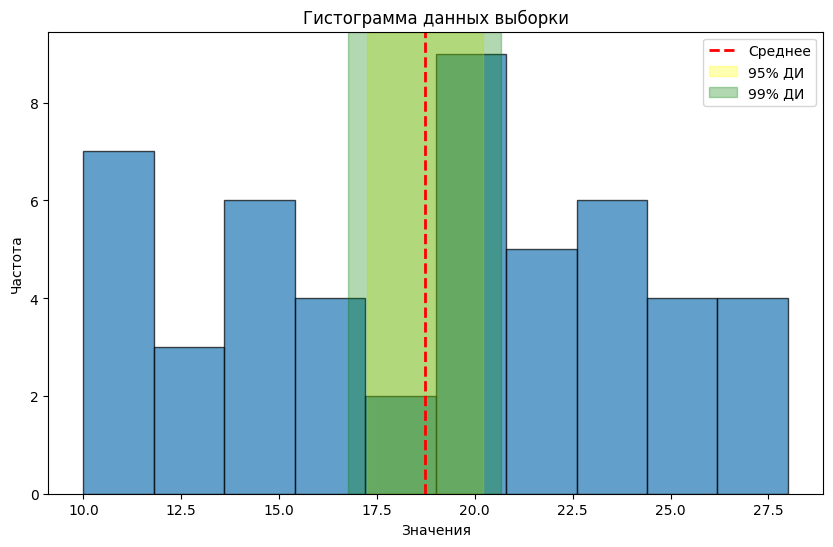

In [20]:
# Постройте визуализацию
# Построение графика данных выборки
plt.figure(figsize=(10, 6))
plt.hist(data, bins=10, edgecolor='black', alpha=0.7)
plt.title("Гистограмма данных выборки")
plt.xlabel("Значения")
plt.ylabel("Частота")
plt.axvline(sample_mean, color='red', linestyle='dashed', linewidth=2, label='Среднее')
plt.axvspan(ci_95[0], ci_95[1], color='yellow', alpha=0.3, label='95% ДИ')
plt.axvspan(ci_99[0], ci_99[1], color='green', alpha=0.3, label='99% ДИ')
plt.legend()
plt.show()